# COS30049 Assignment 2 - Group 8



### Importing required python packages

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report



### Help Functions

1. This help funtion will extract the deatures from the email body such as number of character, number of special characters and word count.

In [35]:
def add_features(df):
    susp_words = ['free','win','urgent','bank','prize','verify','account','gift']
    df = df.copy()
    df['num_chars'] = df['Body'].str.len()
    df['num_special_chars'] = df['Body'].str.count(r'[!@#$%^&*(),.?":{}|<>]')
    df['word_count'] = df['Body'].str.split().apply(len)
    df['has_susp'] = df['Body'].apply(lambda x: int(any(w in x for w in susp_words)))
    df['num_links'] = df['Body'].str.count(r"http")

    return df[['num_chars', 'num_special_chars', 'word_count', 'has_susp', 'num_links']]

## Data Processing

### Loading the datasets

1. Load the first dataset into a dataframe (from a csv) that has been downloaded from Kaggle, this dataset contains spam and ham email messages

In [36]:
# Load the dataset into a dataframe
email_df = pd.read_csv('datasets/completeSpamAssassin.csv', index_col=0)

email_df['Body'] = email_df['Body'].str.replace(r'\n', ' ', regex=True)

2. Load the second dataset into a new dataframe, this dataset contains spam and ham SMS messages.

In [37]:
# Loading the second dataset into a new dataframe
sms_df = pd.read_csv('datasets/spam.csv', encoding='latin-1')
print(len(sms_df))

5572


3. The SMS dataframe contains weird column names, time to change these column names so they are the same as the first dataframe.

In [38]:
# Keep only the columns we need and rename them to match the first dataframe
sms_df = sms_df[['v1', 'v2']]
sms_df = sms_df.rename(columns={'v1': 'Label', 'v2': 'Body'})

4. The email dataframe contains the values of 1 and 0 in the 'Label' column, we want to now change this to be 'spam' and 'ham' so that it matches the SMS dataframe.

In [39]:
# Map 'spam' to 1 and 'ham' to 0
email_df['Label'] = email_df['Label'].map({1: 'spam', 0: 'ham'})

4. The two dataframes will now be joined together to form one large dataframe.

In [40]:
# Join the two dataframes into a single dataframe using concat
df = pd.concat([email_df, sms_df], ignore_index=True)


5. The fifth step of cleaning and processing the data is to remove missing values. After evaluating the documentation provided with the spam email dataset we learned that 9% of entries into this dataset contain the word 'empty' in the 'Body' column. So for this step we will remove rows with missing values and rows with 'Empty' in the body.

In [41]:
# Removal of the rows with 'empty' in the 'Body' column
df = df[df['Body'] != 'empty']

# Remove rows with missing values
df = df.dropna()

2. This code returns a new dataframe only containing the extracted features, and not whether or not it's spam. For the purpose of further data analysis on these features I will add the label to this dataframe.

### Saving the cleaned data set as CSV

In [42]:
df.to_csv('datasets/clean_dataset.csv', index=False)

## Data Analysis

### Feature extraction for analysis

The first step of analysis is to create a new dataframe containing the extracted features about the data that we can use for analysis. The features we have extracted to use are as follows:
* Number of characters in the email body (num_chars)
* Number of special characters in the email body (num_special_chars)
* Word count of the email body (word_count)
* Presence of suspicious words in the email body (has_susp)
* Number of links in the email body (num_links) 

In [43]:
df_features = add_features(df) # Create a new dataframe with the extracted features
df_features['Label'] = df['Label'].values # Add the 'Label' column to the features dataframe for analysis

### Using the extracted features for analysis

#### Number of characters

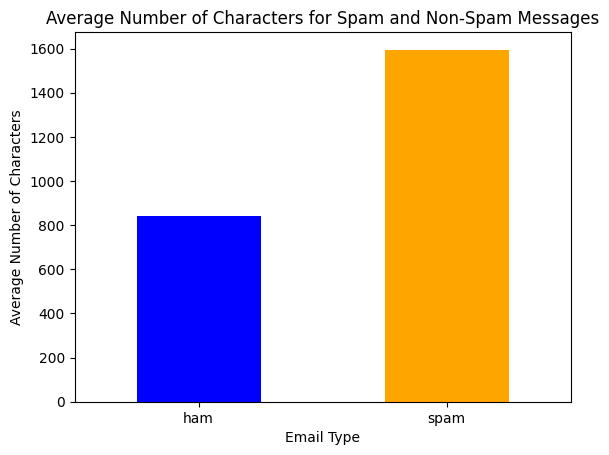

In [44]:
# Calculate the average number of characters for spam and ham emails
avg_chars = df_features.groupby('Label')['num_chars'].mean()

# Plot the bar chart
avg_chars.plot(kind='bar', color=['blue', 'orange'])
plt.title('Average Number of Characters for Spam and Non-Spam Messages')
plt.xlabel('Email Type')
plt.ylabel('Average Number of Characters')
plt.xticks(rotation=0)
plt.show()

#### Number of special characters

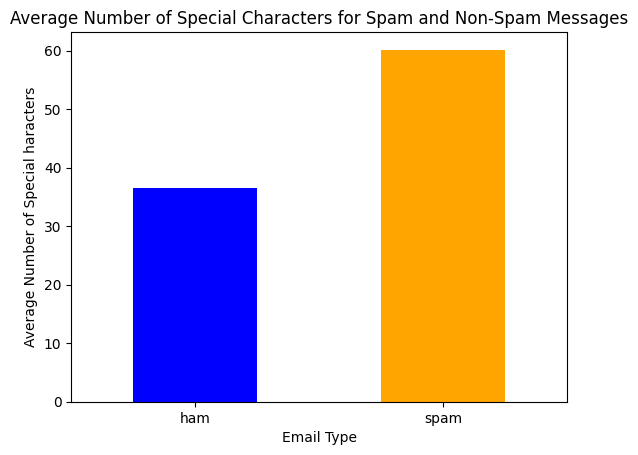

In [45]:
avg_special_chars = df_features.groupby('Label')['num_special_chars'].mean()
avg_special_chars.plot(kind='bar', color=['blue', 'orange'])
plt.title('Average Number of Special Characters for Spam and Non-Spam Messages')
plt.xlabel('Email Type')
plt.ylabel('Average Number of Special haracters')
plt.xticks(rotation=0)
plt.show()

#### Word Count

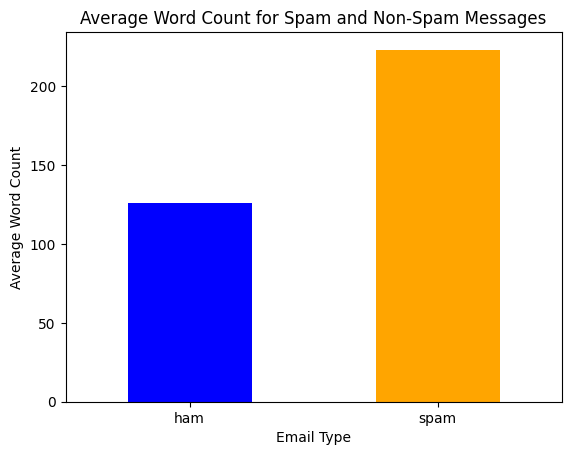

In [46]:
avg_words = df_features.groupby('Label')['word_count'].mean()
avg_words.plot(kind='bar', color=['blue', 'orange'])
plt.title('Average Word Count for Spam and Non-Spam Messages')
plt.xlabel('Email Type')
plt.ylabel('Average Word Count')
plt.xticks(rotation=0)
plt.show()

#### Has Suspicious Words

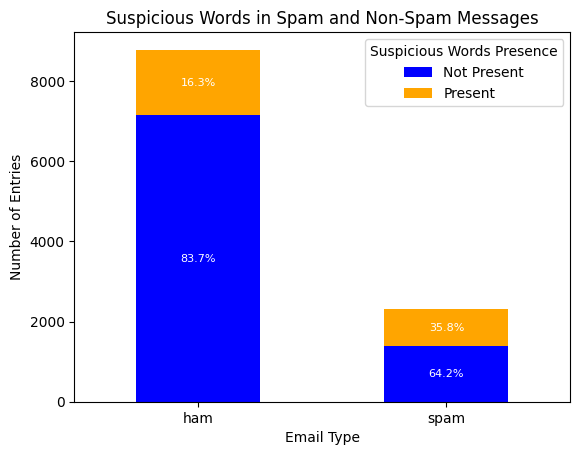

In [47]:
grouped_data = df_features.groupby(['Label', 'has_susp']).size().unstack()
grouped_data.plot(kind='bar', stacked=True, color=['blue', 'orange'])
plt.title('Suspicious Words in Spam and Non-Spam Messages')
plt.xlabel('Email Type')
plt.ylabel('Number of Entries')
plt.xticks(rotation=0)
plt.legend(title='Suspicious Words Presence', labels=['Not Present', 'Present'])

percentages = grouped_data.div(grouped_data.sum(axis=0), axis=1) * 100

for i, bar_group in enumerate(plt.gca().containers):
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only annotate non-zero bars
            plt.gca().text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f'{percentages.iloc[i, bar_group.index(bar)]:.1f}%',
                ha='center',
                va='center',
                fontsize=8,
                color='white'
            )
plt.show()

#### Number of Links

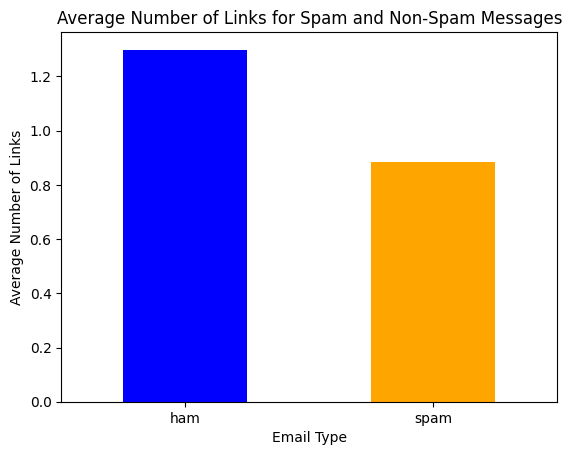

In [48]:
avg_links = df_features.groupby('Label')['num_links'].mean()
avg_links.plot(kind='bar', color=['blue', 'orange'])
plt.title('Average Number of Links for Spam and Non-Spam Messages')
plt.xlabel('Email Type')
plt.ylabel('Average Number of Links')
plt.xticks(rotation=0)
plt.show()

## Machine Learning

### Model Training: Logistical Regression

1. The first step of training the model is to split the data into training and testing data. The training data will be used to train the model, and the testing data will be used to evaluate the models accuracy.

In [49]:
# Split the data into training and testing data sets
X_train, X_test, y_train, y_test = train_test_split(df[['Body']], df['Label'], test_size=0.2, random_state=42)

2. The next step of training the classification model is to create a preprocessor that applies different preprocessing steps to different columns, for the 'Body' column we will apply TF-IDF vectorization to convert the text data into numerical data, and for the second column it will also use the body data but will extract the features from the data using the help function created earlier, the extracted features will then be scaled using standard scaling.

In [50]:
# Creates a column transformer that applies different preprocessing steps to different columns
preprocessor = ColumnTransformer(
    # Preprocess text and numeric features separately
    transformers=[
        # Process text features using TfidfVectorizer
        ('text', TfidfVectorizer(), 'Body'),
        # Process numeric features using a pipeline that adds features using the add_features help function and scales them
        ('num', Pipeline([
            ('features', FunctionTransformer(add_features, validate=False)),
            ('scaler', StandardScaler())
        ]), ['Body'])  # Uses the body column to extract the numeric features
    ]
)

3. Next we create a pipeline that first applies the preprocessor to the data, and then applies the classification model. For this model we used logistic regression as the classification model.

In [51]:
# Creates a pipeline that uses preprocessor to process the data then uses the logistic regression classifier
clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

4. The final step of training the classification model is to actually fit the training data to the model. After doing so, the model is ready to be evaluated.

In [52]:
# Trains the model using the training data
clf.fit(X_train, y_train)

# Predicts the labels for the testing data
y_pred = clf.predict(X_test)

### Model Evaluation: Logistical Regression

1. First step of evaluation of the model is to calculate the accuracy of the model busing both the training and testing data.

In [53]:

# Evaluates the accuracy of the model (both testing and training)
print("Training Accuracy:", clf.score(X_train, y_train))
print("Test Accuracy:", clf.score(X_test, y_test))


#  Classification Report 
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.9757500563952177
Test Accuracy: 0.9612088407758231

Classification Report:

              precision    recall  f1-score   support

         ham       0.96      0.99      0.98      1739
        spam       0.97      0.85      0.90       478

    accuracy                           0.96      2217
   macro avg       0.97      0.92      0.94      2217
weighted avg       0.96      0.96      0.96      2217



2. The next step of evaluation of this model is to create a confusion matrix so that we can visualise the accuracy of the model.

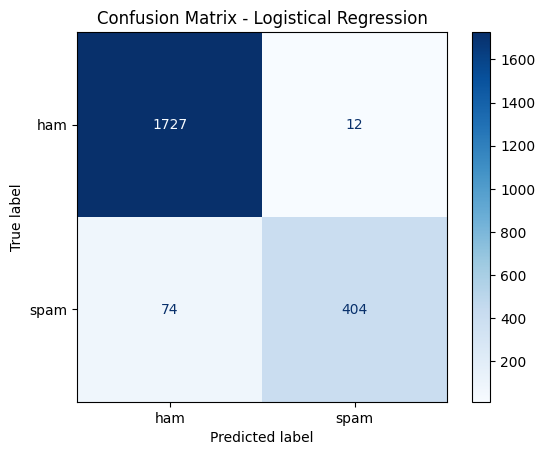

In [54]:
# Creates the confusion matrix using the true labels and the predicted labels
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

# Creates a visualisation of the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistical Regression")
plt.show()


### Model Training: Multinomial Naive Bayes

For the rest of the models we will skip documenting the specific steps of training each model as they are the same as the steps taken for training the logistical regression model, the only difference is the classification model used in the pipeline which will be changed to the relevant model.

One difference for this model is that we will be using Min-Max scaling for the extracted features, this is because the Multinomial Naive Bayes model only works with non-negative values.

In [55]:
# Creates a column transformer that applies different preprocessing steps to different columns
mnb_preprocessor = ColumnTransformer(
    # Preprocess text and numeric features separately
    transformers=[
        # Process text features using TfidfVectorizer
        ('text', TfidfVectorizer(), 'Body'),
        # Process numeric features using a pipeline that adds features using the add_features help function and scales them
        ('num', Pipeline([
            ('features', FunctionTransformer(add_features, validate=False)),
            ('scaler', MinMaxScaler())
        ]), ['Body'])  # Uses the body column to extract the numeric features
    ]
)

# Multinomial Naive Bayes Pipeline
mnb_clf = Pipeline([
    ('preprocessor', mnb_preprocessor),
    ('classifier', MultinomialNB())
])

# Train the model
mnb_clf.fit(X_train, y_train)

# Predictions
y_pred = mnb_clf.predict(X_test)

### Model Evaluation: Multinomial Naive Bayes

In [56]:
#  Evaluate Model 
print("Training Accuracy:", mnb_clf.score(X_train, y_train))
print("Test Accuracy:", mnb_clf.score(X_test, y_test))

#  Classification Report 
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.8984886081660275
Test Accuracy: 0.8655841226883175

Classification Report:

              precision    recall  f1-score   support

         ham       0.85      1.00      0.92      1739
        spam       1.00      0.38      0.55       478

    accuracy                           0.87      2217
   macro avg       0.93      0.69      0.73      2217
weighted avg       0.89      0.87      0.84      2217



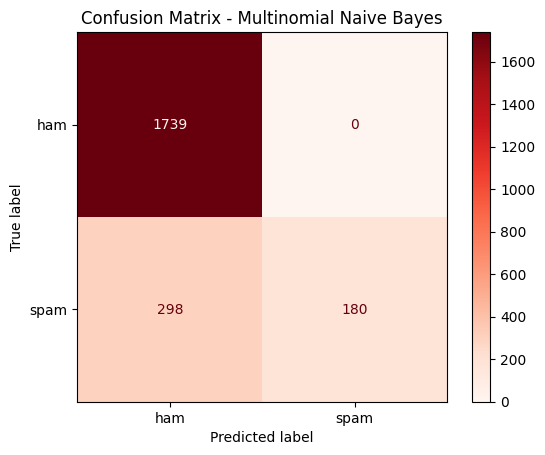

In [57]:
#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred, labels=mnb_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mnb_clf.classes_)
disp.plot(cmap=plt.cm.Reds)
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()

### Model Training: SVM

Once again there will be no documentation of the specific steps taken because it is almost identical to the steps taken for training the logistical regression model.

In [58]:
# SVM Pipeline
svm_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear', random_state=42))
])

# Train the model
svm_clf.fit(X_train, y_train)

# Predictions
y_pred = svm_clf.predict(X_test)

### Model Evaluation: SVM

In [59]:
#  Evaluate Model 
print("Training Accuracy:", svm_clf.score(X_train, y_train))
print("Test Accuracy:", svm_clf.score(X_test, y_test))

#  Classification Report 
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.9972930295510941
Test Accuracy: 0.9810554803788903

Classification Report:

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99      1739
        spam       0.98      0.93      0.95       478

    accuracy                           0.98      2217
   macro avg       0.98      0.96      0.97      2217
weighted avg       0.98      0.98      0.98      2217



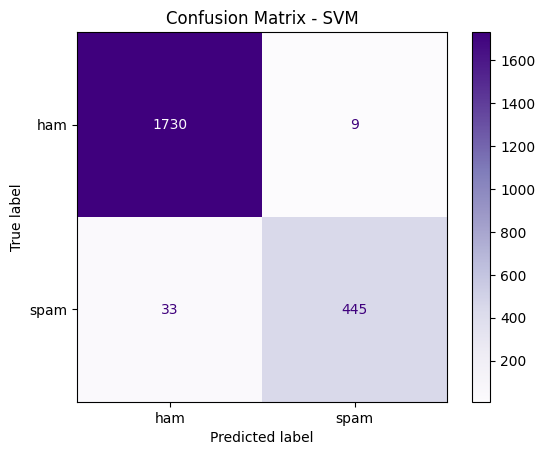

In [60]:
#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred, labels=svm_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_clf.classes_)
disp.plot(cmap=plt.cm.Purples)
plt.title("Confusion Matrix - SVM")
plt.show()

### Model Training: Random Forest Classifier

Once again there will be no documentation of the specific steps taken because it is almost identical to the steps taken for training the logistical regression model.

In [61]:
#  Random Forest Classifier Pipeline to ensure preprocessing applies automatically during training and prediction
rf_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,       # number of trees
        max_depth=None,         # let trees expand until pure
        random_state=42,
        n_jobs=-1               # use all CPU cores
    ))
])

#  Train Model 
rf_clf.fit(X_train, y_train)

# Predictions
y_pred = rf_clf.predict(X_test)

### Model Evaluation: Random Forest Classifier

In [62]:
#  Evaluate Model 
print("Training Accuracy:", rf_clf.score(X_train, y_train))
print("Test Accuracy:", rf_clf.score(X_test, y_test))

#  Classification Report 
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Training Accuracy: 1.0
Test Accuracy: 0.9670726206585476

Classification Report:

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1739
        spam       1.00      0.85      0.92       478

    accuracy                           0.97      2217
   macro avg       0.98      0.93      0.95      2217
weighted avg       0.97      0.97      0.97      2217



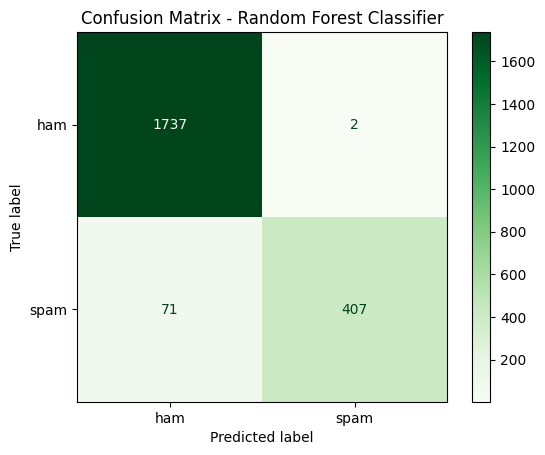

In [63]:
#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred, labels=rf_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_clf.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()